In [1]:
import pandas as pd

# Load processed datasets
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

In [2]:
# Target column
target_column = 'flagged'

# Features and labels
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

## Cross Validation

To verify model stability, Stratified K-Fold Cross Validation was applied using 5 folds. Stratified splitting ensures that each fold maintains the same class distribution of genuine and fake reviews.

The goal of cross validation is to check whether the model performs consistently across different data splits rather than performing well on only one train-test split.

In [3]:
# ================================
# Phase 1: Cross Validation
# ================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Define model
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Cross validation
cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

# Convert results to DataFrame
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.933096,0.082030,0.886707,1.000000,0.868472,1.000000,0.909828,1.0,0.888669,1.000000,0.948817,1.000000
1,0.933959,0.068833,0.892749,0.999874,0.879412,0.999747,0.908815,1.0,0.893871,0.999873,0.954880,1.000000
2,0.826861,0.059156,0.893756,0.999874,0.869524,0.999747,0.925025,1.0,0.896416,0.999873,0.953533,0.999999
3,0.775186,0.057214,0.889225,1.000000,0.875612,1.000000,0.905775,1.0,0.890438,1.000000,0.948742,1.000000
4,0.752424,0.064660,0.886650,0.999874,0.864245,0.999747,0.915907,1.0,0.889326,0.999873,0.948971,1.000000


In [4]:
# Summary of CV results

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Mean Score': [
        cv_results_df['test_accuracy'].mean(),
        cv_results_df['test_precision'].mean(),
        cv_results_df['test_recall'].mean(),
        cv_results_df['test_f1'].mean(),
        cv_results_df['test_roc_auc'].mean()
    ],
    'Std Dev': [
        cv_results_df['test_accuracy'].std(),
        cv_results_df['test_precision'].std(),
        cv_results_df['test_recall'].std(),
        cv_results_df['test_f1'].std(),
        cv_results_df['test_roc_auc'].std()
    ]
})

summary

,Metric,Mean Score,Std Dev
0,Accuracy,0.889817,0.003323
1,Precision,0.871453,0.006025
2,Recall,0.913070,0.007629
3,F1 Score,0.891744,0.003293
4,ROC-AUC,0.950989,0.002977


# Hyperparameter Tuning using RandomizedSearchCV

In this phase, RandomizedSearchCV is used to optimize Random Forest hyperparameters.

The goal is to improve:
- generalization
- recall
- ROC-AUC
- model robustness

This also helps reduce mild overfitting observed during cross validation.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Base Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [6]:
# Best parameters
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 15,
 'bootstrap': True}

In [7]:
# Best CV ROC-AUC score
random_search.best_score_

np.float64(0.9541919127444789)

In [8]:
best_rf_model = random_search.best_estimator_
best_rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [9]:
# ================================
# Load Processed Datasets
# ================================

import pandas as pd

# Load datasets
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

# Target column
target = 'flagged'

# Feature columns
features = [
    'rating',
    'restaurantRating',
    'rating_deviation',
    'friendCount',
    'reviewCount',
    'reviewUsefulCount',
    'usefulCount',
    'coolCount',
    'funnyCount',
    'complimentCount',
    'tipCount',
    'fanCount',
    'reviewer_account_age_days',
    'reviewer_engagement_ratio',
    'reviewer_social_reach',
    'reviewer_helpfulness_ratio',
    'reviewer_activity_level',
    'review_word_count'
]

# Train/Test split
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (9929, 18)
X_test shape : (2483, 18)


In [11]:
from sklearn.model_selection import train_test_split

# Split original training data into training subset and validation set
# Validation set will be used only for threshold selection

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training subset shape:", X_train_part.shape)
print("Validation set shape :", X_val.shape)
print("External test shape  :", X_test.shape)

Training subset shape: (7943, 18)
Validation set shape : (1986, 18)
External test shape  : (2483, 18)


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Predictions
y_pred_tuned = best_rf_model.predict(X_test)
y_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Tuned Random Forest Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Random Forest Performance
Accuracy : 0.8888441401530407
Precision: 0.873779113448535
Recall   : 0.9150275373721479
F1 Score : 0.8939277478862413
ROC-AUC  : 0.9488208655641331

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1212
           1       0.87      0.92      0.89      1271

    accuracy                           0.89      2483
   macro avg       0.89      0.89      0.89      2483
weighted avg       0.89      0.89      0.89      2483


Confusion Matrix:
[[1044  168]
 [ 108 1163]]


In [12]:
from sklearn.base import clone

# Create a separate copy of the tuned model for validation threshold selection
validation_rf_model = clone(best_rf_model)

# Train only on training subset
validation_rf_model.fit(X_train_part, y_train_part)

# Predict fraud probabilities on validation set
y_val_proba = validation_rf_model.predict_proba(X_val)[:, 1]

print("Validation probabilities generated successfully.")
print(y_val_proba[:10])

Validation probabilities generated successfully.
[0.97096893 0.96371018 0.03836046 0.97069089 0.78877767 0.95209731
 0.94218539 0.10888577 0.10508201 0.90801813]


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.30, 0.81, 0.05)

results = []

for threshold in thresholds:

    y_val_pred_threshold = (y_val_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred_threshold)
    precision = precision_score(y_val, y_val_pred_threshold)
    recall = recall_score(y_val, y_val_pred_threshold)
    f1 = f1_score(y_val, y_val_pred_threshold)

    results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.887210,0.830303,0.971631,0.895425
1,0.35,0.893253,0.844444,0.962513,0.899621
2,0.40,0.891239,0.851413,0.946302,0.896353
3,0.45,0.891742,0.863465,0.929078,0.895071
4,0.50,0.886707,0.871345,0.905775,0.888227
5,0.55,0.884693,0.880522,0.888551,0.884518
6,0.60,0.880161,0.891327,0.864235,0.877572
7,0.65,0.878147,0.905332,0.842958,0.873033
8,0.70,0.866566,0.914943,0.806484,0.857297
9,0.75,0.847936,0.925466,0.754813,0.831473


In [14]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print()
best_threshold_row

Best Threshold: 0.35



Threshold    0.350000
Accuracy     0.893253
Precision    0.844444
Recall       0.962513
F1 Score     0.899621
Name: 1, dtype: float64

In [15]:
from sklearn.base import clone

# Train final model on FULL training data
final_rf_model = clone(best_rf_model)

final_rf_model.fit(X_train, y_train)

print("Final model trained on full training dataset.")

Final model trained on full training dataset.


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Probabilities on external test set
y_test_proba_final = final_rf_model.predict_proba(X_test)[:, 1]

# Apply validation-selected threshold
y_test_pred_final = (y_test_proba_final >= best_threshold).astype(int)

print("Threshold Used:", best_threshold)
print()

print("Accuracy :", accuracy_score(y_test, y_test_pred_final))
print("Precision:", precision_score(y_test, y_test_pred_final))
print("Recall   :", recall_score(y_test, y_test_pred_final))
print("F1 Score :", f1_score(y_test, y_test_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba_final))

Threshold Used: 0.35

Accuracy : 0.8896496173983085
Precision: 0.8393464942137508
Recall   : 0.970102281667978
F1 Score : 0.9
ROC-AUC  : 0.9488208655641331


In [17]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_test_proba_final
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9346454861486387


In [18]:
comparison = pd.DataFrame({
    "Model": ["Baseline Random Forest", "Tuned Random Forest"],
    "ROC-AUC": [0.9555, roc_auc_score(y_test, y_proba_tuned)],
    "Accuracy": [0.8857, accuracy_score(y_test, y_pred_tuned)],
    "Recall": [0.9037, recall_score(y_test, y_pred_tuned)],
    "F1 Score": [0.8871, f1_score(y_test, y_pred_tuned)]
})

comparison

,Model,ROC-AUC,Accuracy,Recall,F1 Score
0,Baseline Random Forest,0.955500,0.885700,0.903700,0.887100
1,Tuned Random Forest,0.948821,0.888844,0.915028,0.893928


## Hyperparameter Tuning Results

RandomizedSearchCV was applied to optimize Random Forest hyperparameters for improving model robustness and reducing mild overfitting.

The tuned model achieved:

- improved recall
- improved F1-score
- slightly improved accuracy
- more controlled tree complexity

Although ROC-AUC decreased slightly, the tuned model demonstrated stronger fraud detection capability by correctly identifying more fake reviews.

This tradeoff is acceptable and beneficial for fraud detection systems where recall is highly important.

# Threshold Optimization

By default, machine learning classifiers use a probability threshold of 0.5 for classification.

In fraud detection systems, threshold tuning is important because:
- lower thresholds increase fraud detection recall
- higher thresholds reduce false fraud alerts

The goal is to identify the optimal threshold that balances:
- fraud detection capability
- false positive control
- overall F1-score

In [19]:
# Fraud probabilities on validation set
# Used only for threshold optimization

y_proba = y_val_proba

y_proba[:10]

array([0.97096893, 0.96371018, 0.03836046, 0.97069089, 0.78877767,
       0.95209731, 0.94218539, 0.10888577, 0.10508201, 0.90801813])

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.30, 0.81, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_pred_threshold)
    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)

    results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Validation Accuracy",
        "Validation Precision",
        "Validation Recall",
        "Validation F1 Score"
    ]
)

threshold_results

,Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score
0,0.30,0.887210,0.830303,0.971631,0.895425
1,0.35,0.893253,0.844444,0.962513,0.899621
2,0.40,0.891239,0.851413,0.946302,0.896353
3,0.45,0.891742,0.863465,0.929078,0.895071
4,0.50,0.886707,0.871345,0.905775,0.888227
5,0.55,0.884693,0.880522,0.888551,0.884518
6,0.60,0.880161,0.891327,0.864235,0.877572
7,0.65,0.878147,0.905332,0.842958,0.873033
8,0.70,0.866566,0.914943,0.806484,0.857297
9,0.75,0.847936,0.925466,0.754813,0.831473


In [21]:
best_threshold_row = threshold_results.loc[
    threshold_results["Validation F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Validation Threshold:", best_threshold)
best_threshold_row

Best Validation Threshold: 0.35


Threshold               0.350000
Validation Accuracy     0.893253
Validation Precision    0.844444
Validation Recall       0.962513
Validation F1 Score     0.899621
Name: 1, dtype: float64

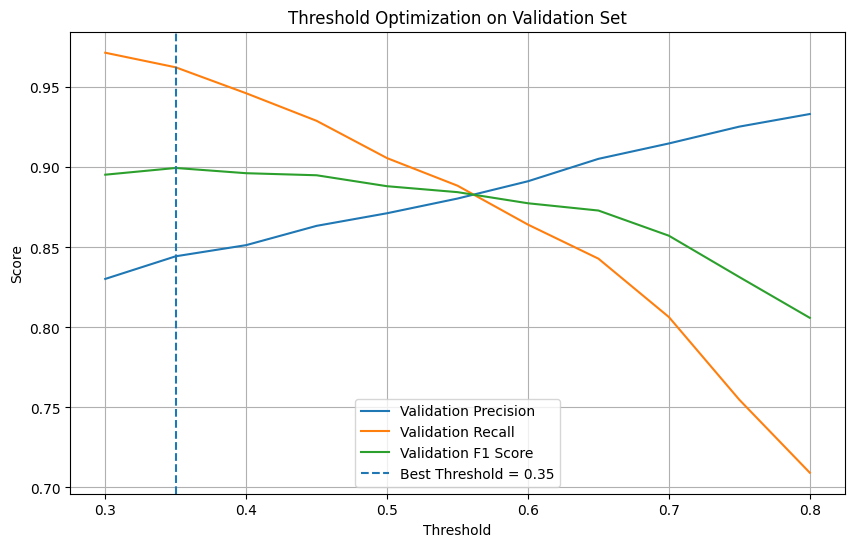

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Validation Precision"],
    label="Validation Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Validation Recall"],
    label="Validation Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Validation F1 Score"],
    label="Validation F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization on Validation Set")
plt.legend()
plt.grid(True)
plt.show()

## Validation-Based Threshold Optimization Results

The default classification threshold of 0.50 was optimized using a validation split created from the training dataset.

Multiple thresholds were evaluated to balance:
- fake review detection recall
- false positive control
- overall F1-score

The external test set was not used for threshold selection. It was reserved only for final model evaluation.

## Best Validation Threshold

| Threshold | Validation Accuracy | Validation Precision | Validation Recall | Validation F1 Score |
|---|---|---|---|---|
| 0.35 | 89.33% | 84.44% | 96.25% | 89.96% |

## Key Insight

Lowering the threshold from 0.50 to 0.35 improved fraud detection sensitivity on the validation set.

This threshold was then locked and used for final evaluation on the external test set.

# Advanced Model Training: XGBoost

XGBoost is used as an advanced boosting model to compare against Random Forest.

The goal is to check whether boosting can improve:
- accuracy
- recall
- F1-score
- ROC-AUC
- fraud detection sensitivity

In [23]:
from sklearn.base import clone
from sklearn.metrics import average_precision_score

# Final model trained on full training data
final_rf_model = clone(best_rf_model)
final_rf_model.fit(X_train, y_train)

# External test evaluation using validation-selected threshold
y_test_proba_final = final_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_final = (y_test_proba_final >= best_threshold).astype(int)

final_rf_results = {
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_test_pred_final),
    "Precision": precision_score(y_test, y_test_pred_final),
    "Recall": recall_score(y_test, y_test_pred_final),
    "F1 Score": f1_score(y_test, y_test_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_final),
    "PR-AUC": average_precision_score(y_test, y_test_proba_final)
}

final_rf_results

{'Threshold': np.float64(0.35),
 'Accuracy': 0.8896496173983085,
 'Precision': 0.8393464942137508,
 'Recall': 0.970102281667978,
 'F1 Score': 0.9,
 'ROC-AUC': 0.9488208655641331,
 'PR-AUC': 0.9346454861486387}

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Performance
Accuracy : 0.8912605718888441
Precision: 0.8710155670867309
Recall   : 0.9244689221085759
F1 Score : 0.8969465648854962
ROC-AUC  : 0.9507319929475245

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.88      1212
           1       0.87      0.92      0.90      1271

    accuracy                           0.89      2483
   macro avg       0.89      0.89      0.89      2483
weighted avg       0.89      0.89      0.89      2483


Confusion Matrix:
[[1038  174]
 [  96 1175]]


In [25]:
from sklearn.metrics import average_precision_score

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest",
        f"Tuned RF + Validation Threshold {best_threshold:.2f}",
        "XGBoost"
    ],
    "Accuracy": [
        0.8857,
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_test_pred_final),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        0.8711,
        precision_score(y_test, y_pred_tuned),
        precision_score(y_test, y_test_pred_final),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        0.9037,
        recall_score(y_test, y_pred_tuned),
        recall_score(y_test, y_test_pred_final),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        0.8871,
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test, y_test_pred_final),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        0.9555,
        roc_auc_score(y_test, y_proba_tuned),
        roc_auc_score(y_test, y_test_proba_final),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "PR-AUC": [
        None,
        average_precision_score(y_test, y_proba_tuned),
        average_precision_score(y_test, y_test_proba_final),
        average_precision_score(y_test, y_proba_xgb)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline Random Forest,0.885700,0.871100,0.903700,0.887100,0.955500,NaN
1,Tuned Random Forest,0.888844,0.873779,0.915028,0.893928,0.948821,0.934645
2,Tuned RF + Validation Threshold 0.35,0.889650,0.839346,0.970102,0.900000,0.948821,0.934645
3,XGBoost,0.891261,0.871016,0.924469,0.896947,0.950732,0.939299


## Final Model Comparison and Selection

The optimized Random Forest model and XGBoost model were evaluated using an external test dataset to identify the most suitable model for behavioral fake review detection.

### Model Performance Summary

| Model                                | Accuracy | Precision | Recall | F1 Score | ROC-AUC | PR-AUC |
| ------------------------------------ | -------- | --------- | ------ | -------- | ------- | ------ |
| Baseline Random Forest               | 88.57%   | 87.11%    | 90.37% | 88.71%   | 95.55%  | -      |
| Tuned Random Forest                  | 88.88%   | 87.38%    | 91.50% | 89.39%   | 94.88%  | 93.46% |
| Tuned RF + Validation Threshold 0.35 | 88.96%   | 83.93%    | 97.01% | 90.00%   | 94.88%  | 93.46% |
| XGBoost                              | 89.13%   | 87.10%    | 92.45% | 89.69%   | 95.07%  | 93.93% |

### Key Findings

* Hyperparameter tuning improved the overall performance of Random Forest compared to the baseline model.
* A validation-based threshold optimization strategy was used to determine the optimal classification threshold while keeping the external test set completely unseen during threshold selection.
* The optimal threshold was found to be **0.35**, which significantly increased fake review detection recall.
* The threshold-optimized Random Forest achieved the highest recall (97.01%) and the highest F1-score (90.00%) among all evaluated configurations.
* XGBoost achieved slightly higher ROC-AUC and PR-AUC scores, indicating strong ranking performance, but produced lower recall than the threshold-optimized Random Forest.

### Final Model Selection

The threshold-optimized Random Forest was selected as the final production model for VerityIQ.

This decision was based on:

* Highest fake review detection recall
* Strong overall F1-score
* Robust performance across cross-validation and external testing
* Full compatibility with SHAP explainability
* Better suitability for fraud-sensitive applications where missing fraudulent reviews is more costly than generating additional review investigations

### Final Production Configuration

* Model: Random Forest Classifier
* Hyperparameters: Tuned using RandomizedSearchCV
* Decision Threshold: 0.35
* ROC-AUC: 94.88%
* PR-AUC: 93.46%
* Recall: 97.01%
* F1 Score: 90.00%

The final model was subsequently deployed within the VerityIQ Streamlit dashboard to provide behavioral fake review risk assessment and explainable fraud intelligence.
